<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/AVCAD-EXERCISE/blob/main/Exercise7_Preprocessing_Correlation_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.ensemble import IsolationForest

In [16]:
# Load dataset

df = pd.read_csv(
    "EFIplus_medit.csv",
    sep=';'
)

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [17]:
print(df.columns.tolist())

['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophication', 'Organic_p

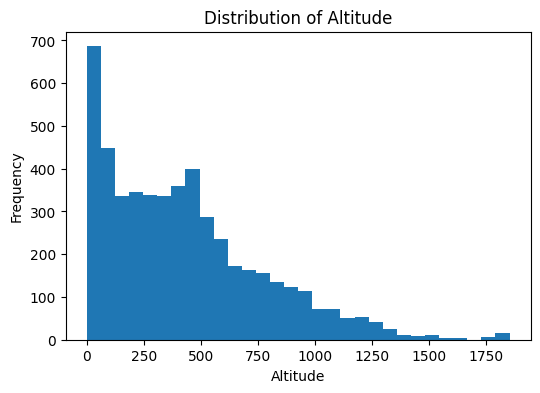

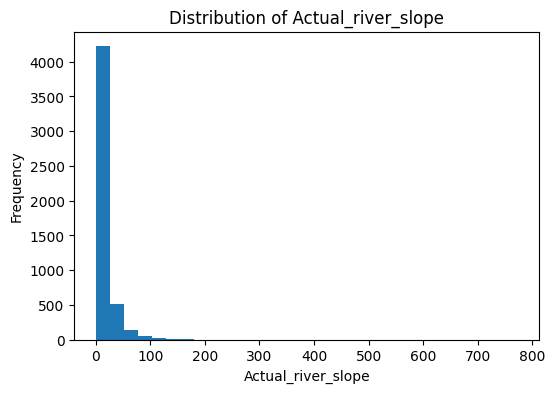

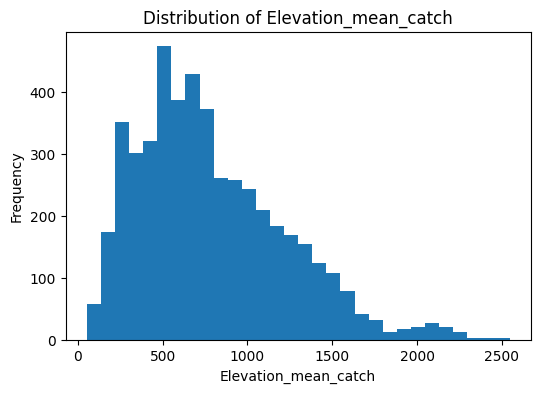

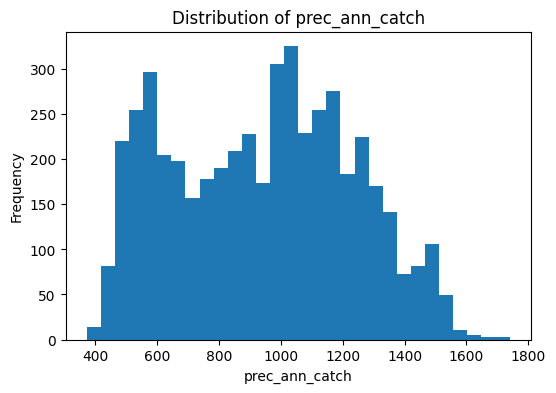

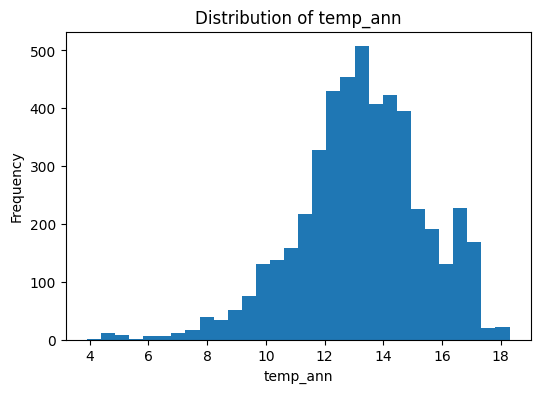

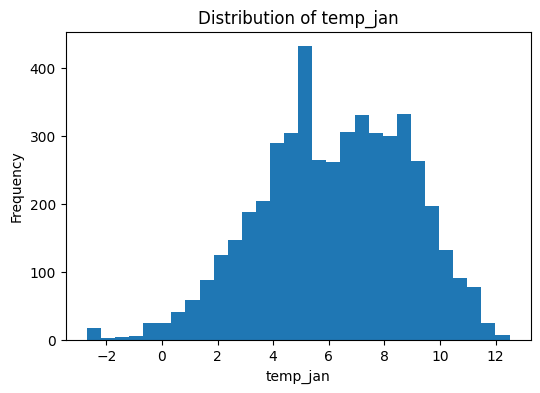

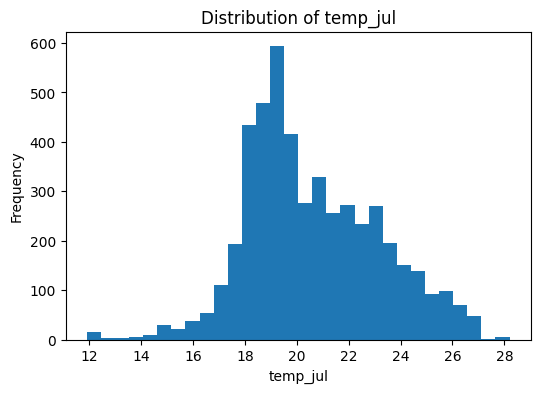

In [18]:
# Environmental variables

variables = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

# Histograms

for var in variables:

    plt.figure(figsize=(6,4))

    plt.hist(
        pd.to_numeric(df[var], errors='coerce').dropna(),
        bins=30
    )

    plt.title(f"Distribution of {var}")

    plt.xlabel(var)
    plt.ylabel("Frequency")

    plt.show()

# Environmental variables

variables = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

# Histograms

for var in variables:

    plt.figure(figsize=(6,4))

    plt.hist(
        pd.to_numeric(df[var], errors='coerce').dropna(),
        bins=30
    )

    plt.title(f"Distribution of {var}")

    plt.xlabel(var)
    plt.ylabel("Frequency")

    plt.show()

In [19]:
# Log transformation

df['log_prec_ann_catch'] = np.log1p(
    df['prec_ann_catch']
)

df['log_Altitude'] = np.log1p(
    df['Altitude']
)

print(df[['prec_ann_catch', 'log_prec_ann_catch']].head())

   prec_ann_catch  log_prec_ann_catch
0      522.071164            6.259718
1      640.327779            6.463541
2      633.238847            6.452426
3      625.841858            6.440694
4      622.111415            6.434725


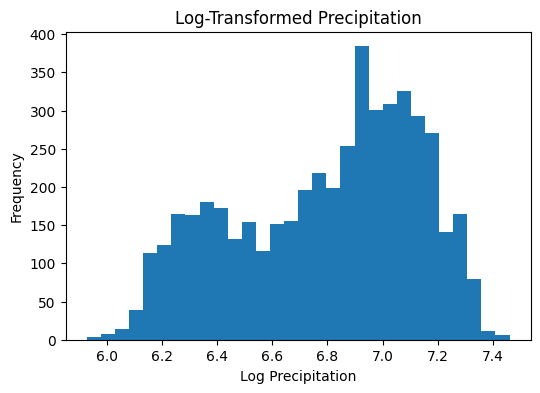

In [20]:
# Histogram of transformed precipitation

plt.figure(figsize=(6,4))

plt.hist(
    df['log_prec_ann_catch'].dropna(),
    bins=30
)

plt.title("Log-Transformed Precipitation")

plt.xlabel("Log Precipitation")
plt.ylabel("Frequency")

plt.show()

# Exercise 2 Interpretation

Log transformation reduced skewness in the environmental variables.

This improves the suitability of the data for parametric statistical analyses.

In [21]:
# Find Abramis brama column position

species_start = df.columns.get_loc(
    'Abramis brama'
)

print(species_start)

56


In [22]:
# Find species column

species_start = df.columns.get_loc(
    'Abramis brama'
)

# Select all species columns

species_columns = df.columns[
    species_start:
]

# Create species richness

df['species_richness'] = df[
    species_columns
].sum(axis=1)

# Check result

print(df['species_richness'].head())

0    12.558035
1    14.597634
2    14.505147
3    15.420770
4    15.361302
Name: species_richness, dtype: float64


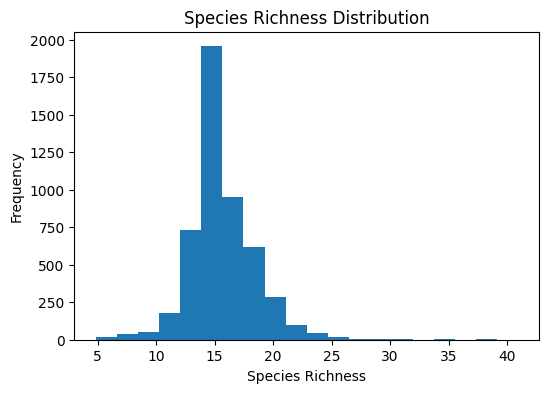

In [23]:
# Histogram of species richness

plt.figure(figsize=(6,4))

plt.hist(
    df['species_richness'],
    bins=20
)

plt.title("Species Richness Distribution")

plt.xlabel("Species Richness")
plt.ylabel("Frequency")

plt.show()

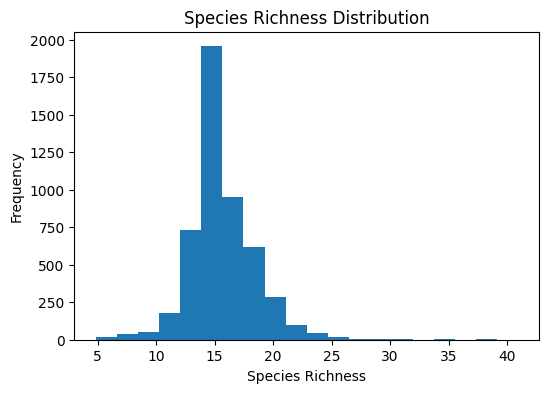

In [24]:
# Histogram of species richness

plt.figure(figsize=(6,4))

plt.hist(
    df['species_richness'],
    bins=20
)

plt.title("Species Richness Distribution")

plt.xlabel("Species Richness")
plt.ylabel("Frequency")

plt.show()

In [25]:
# Select variables for outlier analysis

outlier_data = df[
    ['temp_ann', 'species_richness']
].dropna()

outlier_data.head()

,temp_ann,species_richness
0,17.6,12.558035
1,9.3,14.597634
2,10.1,14.505147
3,10.1,15.420770
4,10.3,15.361302


In [26]:
# Isolation Forest model

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Detect outliers

outlier_data['outlier'] = iso.fit_predict(
    outlier_data
)

print(
    outlier_data['outlier'].value_counts()
)

outlier
 1    4599
-1     242
Name: count, dtype: int64


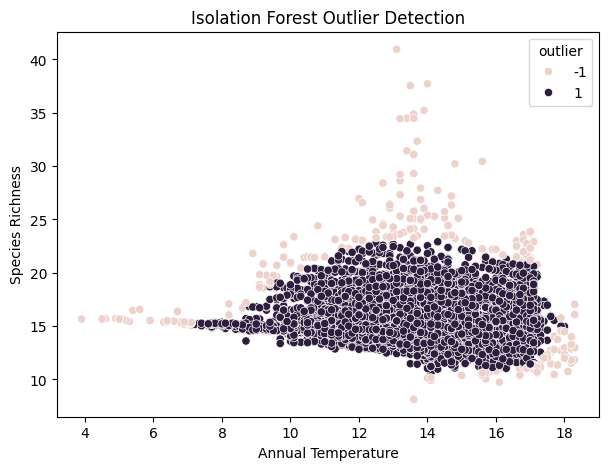

In [27]:
# Plot detected outliers

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=outlier_data,
    x='temp_ann',
    y='species_richness',
    hue='outlier'
)

plt.title(
    "Isolation Forest Outlier Detection"
)

plt.xlabel("Annual Temperature")
plt.ylabel("Species Richness")

plt.show()

# Exercise 4 Interpretation

The scatterplot visualizes the relationship between annual temperature and species richness.

Isolation Forest identified potential bivariate outliers that differ substantially from the overall data pattern.

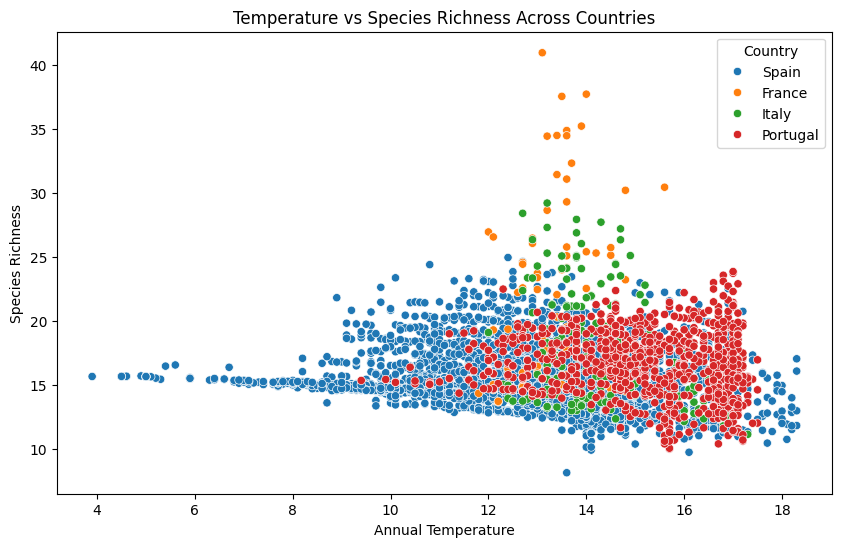

In [28]:
# Relationship across countries

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='temp_ann',
    y='species_richness',
    hue='Country'
)

plt.title(
    "Temperature vs Species Richness Across Countries"
)

plt.xlabel("Annual Temperature")
plt.ylabel("Species Richness")

plt.show()

# Exercise 5 Interpretation

The relationship between annual temperature and species richness varies across countries.

Different countries display different ecological patterns, suggesting that environmental conditions may influence biodiversity differently across regions.